In [2]:
import pandas as pd
import os
import warnings
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
from sklearn.metrics import (precision_score, recall_score, f1_score, accuracy_score,
                             average_precision_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay, PrecisionRecallDisplay)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

warnings.filterwarnings("ignore")

In [3]:
# Version A = training data BEFORE SMOTE (real companies only)
train_A = pd.read_csv("../../data/train_pca.csv")
# Version B = training data AFTER SMOTE (contains fake bankrupt rows)
train_B = pd.read_csv("../../results/outputs/final_preprocessed_train.csv")
# Test data (SMOTE is never applied to this)
test = pd.read_csv("../../results/outputs/final_preprocessed_test.csv")

X_A = train_A.drop(columns="Bankrupt?");  y_A = train_A["Bankrupt?"]
X_B = train_B.drop(columns="Bankrupt?");  y_B = train_B["Bankrupt?"]
X_test = test.drop(columns="Bankrupt?");  y_test = test["Bankrupt?"]

print("Version A:", X_A.shape, y_A.value_counts().to_dict())
print("Version B:", X_B.shape, y_B.value_counts().to_dict())
print("Test     :", X_test.shape, y_test.value_counts().to_dict())

Version A: (5455, 29) {0: 5279, 1: 176}
Version B: (10558, 29) {0: 5279, 1: 5279}
Test     : (1364, 29) {0: 1320, 1: 44}


In [15]:
MEMBER = "IT25101630"                     # <- your name / IT number
MODEL_CHOICE = "Decision Tree"   # <- one of: Logistic Regression, Decision Tree, Random Forest, SVM, KNN, XGBoost, MLP

models = {


    "Decision Tree": (
        DecisionTreeClassifier(random_state=42),
        {"model__max_depth": [3, 5, 8, None],
         "model__min_samples_leaf": [1, 10, 30],
         "model__class_weight": [None, "balanced"]}),

}

base_model, param_grid = models[MODEL_CHOICE]
print("Model:", MODEL_CHOICE)
print("Hyperparameters we will try:", param_grid)
n_combinations = 1
for values in param_grid.values():
    n_combinations = n_combinations * len(values)
print("Combinations per search:", n_combinations, "-> total varieties (x2 for SMOTE yes/no):", n_combinations * 2)

Model: Decision Tree
Hyperparameters we will try: {'model__max_depth': [3, 5, 8, None], 'model__min_samples_leaf': [1, 10, 30], 'model__class_weight': [None, 'balanced']}
Combinations per search: 24 -> total varieties (x2 for SMOTE yes/no): 48


In [5]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_A, y_A)
dummy_predictions = dummy.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, dummy_predictions), 3), " <- looks great, but...")
print("Recall  :", recall_score(y_test, dummy_predictions), " <- catches ZERO bankruptcies")
print("F1      :", f1_score(y_test, dummy_predictions))

Accuracy: 0.968  <- looks great, but...
Recall  : 0.0  <- catches ZERO bankruptcies
F1      : 0.0


In [6]:
# 5 folds, each keeping the same % of bankrupt companies. random_state keeps the folds the same every run.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


def cv_scores(model, X, y):
    """Cross-validate a model and return the average precision, recall and F1."""
    results = cross_validate(model, X, y, cv=cv, scoring=["precision", "recall", "f1"], n_jobs=1)
    return {
        "precision": round(float(results["test_precision"].mean()), 3),
        "recall":    round(float(results["test_recall"].mean()), 3),
        "f1":        round(float(results["test_f1"].mean()), 3),
    }


def evaluate(model, X_test, y_test):
    """Score a TRAINED model on the test set. Returns (scores, confusion matrix)."""
    predictions   = model.predict(X_test)               # 0 or 1 for each company
    probabilities = model.predict_proba(X_test)[:, 1]   # chance of being bankrupt

    scores = {
        "precision": precision_score(y_test, predictions, zero_division=0),
        "recall":    recall_score(y_test, predictions),
        "f1":        f1_score(y_test, predictions),
        "pr_auc":    average_precision_score(y_test, probabilities),
        "roc_auc":   roc_auc_score(y_test, probabilities),
        "accuracy":  accuracy_score(y_test, predictions),   # only to show it is misleading
    }
    matrix = confusion_matrix(y_test, predictions)
    return scores, matrix

In [7]:
model_no_smote   = Pipeline([("model", clone(base_model))])
model_with_smote = Pipeline([("smote", SMOTE(random_state=42)), ("model", clone(base_model))])

scores_no_smote = cv_scores(model_no_smote, X_A, y_A)
scores_smote    = cv_scores(model_with_smote, X_A, y_A)

print("A, no SMOTE               :", scores_no_smote)
print("A, SMOTE inside the folds :", scores_smote)

A, no SMOTE               : {'precision': 0.217, 'recall': 0.262, 'f1': 0.235}
A, SMOTE inside the folds : {'precision': 0.174, 'recall': 0.409, 'f1': 0.243}


In [8]:
scores_wrong = cv_scores(clone(base_model), X_B, y_B)    # WRONG: CV on the already-SMOTEd file
scores_right = scores_smote                              # RIGHT: CV on A, SMOTE inside the folds

print("WRONG (CV on file B)                :", scores_wrong)
print("RIGHT (CV on A, SMOTE inside folds) :", scores_right)

WRONG (CV on file B)                : {'precision': 0.927, 'recall': 0.965, 'f1': 0.946}
RIGHT (CV on A, SMOTE inside folds) : {'precision': 0.174, 'recall': 0.409, 'f1': 0.243}


In [9]:
scoring = {"f1": "f1", "pr_auc": "average_precision"}   # scores recorded for every combination

# --- Search 1: no SMOTE ---
grid_plain = GridSearchCV(
    Pipeline([("model", clone(base_model))]),
    param_grid=param_grid, cv=cv, scoring=scoring, refit="f1", n_jobs=-1)
grid_plain.fit(X_A, y_A)

# --- Search 2: SMOTE inside the folds ---
grid_smote = GridSearchCV(
    Pipeline([("smote", SMOTE(random_state=42)), ("model", clone(base_model))]),
    param_grid=param_grid, cv=cv, scoring=scoring, refit="f1", n_jobs=-1)
grid_smote.fit(X_A, y_A)

print("Search 1 (no SMOTE)   best CV F1:", round(grid_plain.best_score_, 3), "->", grid_plain.best_params_)
print("Search 2 (with SMOTE) best CV F1:", round(grid_smote.best_score_, 3), "->", grid_smote.best_params_)

Search 1 (no SMOTE)   best CV F1: 0.281 -> {'model__class_weight': 'balanced', 'model__max_depth': None, 'model__min_samples_leaf': 10}
Search 2 (with SMOTE) best CV F1: 0.277 -> {'model__class_weight': None, 'model__max_depth': None, 'model__min_samples_leaf': 10}


In [10]:
def make_table(grid, used_smote):
    """Turn one finished GridSearchCV into a small table, one row per combination."""
    results = pd.DataFrame(grid.cv_results_)
    table = pd.DataFrame({
        "SMOTE":     [used_smote] * len(results),
        "settings":  results["params"].astype(str).str.replace("model__", ""),
        "CV F1":     results["mean_test_f1"],
        "CV F1 std": results["std_test_f1"],
        "CV PR-AUC": results["mean_test_pr_auc"],
    })
    return table


all_varieties = pd.concat([make_table(grid_plain, "no"), make_table(grid_smote, "yes")])
all_varieties = all_varieties.sort_values("CV F1", ascending=False)
all_varieties = all_varieties.reset_index(drop=True).round(3)

print(len(all_varieties), "varieties trained")
all_varieties.to_csv("../../results/" + MODEL_CHOICE.replace(" ", "") + "_varieties.csv", index=False)
all_varieties.head(10)

48 varieties trained


,SMOTE,settings,CV F1,CV F1 std,CV PR-AUC
0,no,"{'class_weight': 'balanced', 'max_depth': None...",0.281,0.043,0.212
1,yes,"{'class_weight': 'balanced', 'max_depth': None...",0.277,0.025,0.164
2,yes,"{'class_weight': None, 'max_depth': None, 'min...",0.277,0.025,0.164
3,no,"{'class_weight': 'balanced', 'max_depth': 8, '...",0.275,0.036,0.183
4,no,"{'class_weight': 'balanced', 'max_depth': 8, '...",0.261,0.045,0.202
5,yes,"{'class_weight': 'balanced', 'max_depth': 3, '...",0.257,0.027,0.170
6,yes,"{'class_weight': None, 'max_depth': 3, 'min_sa...",0.257,0.027,0.170
7,yes,"{'class_weight': None, 'max_depth': 3, 'min_sa...",0.256,0.027,0.170
8,yes,"{'class_weight': 'balanced', 'max_depth': 3, '...",0.256,0.027,0.170
9,yes,"{'class_weight': 'balanced', 'max_depth': 3, '...",0.256,0.027,0.170


In [11]:
print("Best CV F1, no SMOTE  :", round(grid_plain.best_score_, 3))
print("Best CV F1, with SMOTE:", round(grid_smote.best_score_, 3))

if grid_plain.best_score_ >= grid_smote.best_score_:
    best_grid = grid_plain
    smote_won = "no"
else:
    best_grid = grid_smote
    smote_won = "yes"

best_settings = best_grid.best_params_
best_model = best_grid.best_estimator_

print()
print("SMOTE used in the winner?:", smote_won)
print("Winning settings         :", best_settings)
print("Best model               :", best_model)

Best CV F1, no SMOTE  : 0.281
Best CV F1, with SMOTE: 0.277

SMOTE used in the winner?: no
Winning settings         : {'model__class_weight': 'balanced', 'model__max_depth': None, 'model__min_samples_leaf': 10}
Best model               : Pipeline(steps=[('model',
                 DecisionTreeClassifier(class_weight='balanced',
                                        min_samples_leaf=10,
                                        random_state=42))])


In [12]:
scores, cm = evaluate(best_model, X_test, y_test)

print("Test scores:")
print("  precision:", round(scores["precision"], 3))
print("  recall   :", round(scores["recall"], 3))
print("  f1       :", round(scores["f1"], 3))
print("  pr_auc   :", round(scores["pr_auc"], 3))
print("  roc_auc  :", round(scores["roc_auc"], 3))
print("  accuracy :", round(scores["accuracy"], 3), "(not used to judge the model)")

tn, fp, fn, tp = cm.ravel()
print()
print("Healthy companies correctly cleared (TN):", tn)
print("False alarms, healthy flagged bankrupt (FP):", fp)
print("Bankruptcies missed (FN):", fn)
print("Bankruptcies caught (TP):", tp)

Test scores:
  precision: 0.187
  recall   : 0.523
  f1       : 0.275
  pr_auc   : 0.184
  roc_auc  : 0.726
  accuracy : 0.911 (not used to judge the model)

Healthy companies correctly cleared (TN): 1220
False alarms, healthy flagged bankrupt (FP): 100
Bankruptcies missed (FN): 21
Bankruptcies caught (TP): 23


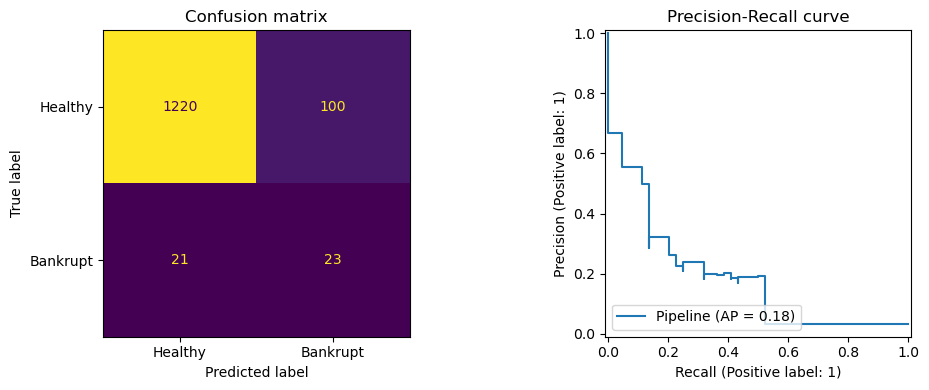

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ConfusionMatrixDisplay(cm, display_labels=["Healthy", "Bankrupt"]).plot(ax=ax[0], colorbar=False)
ax[0].set_title("Confusion matrix")

PrecisionRecallDisplay.from_estimator(best_model, X_test, y_test, ax=ax[1])
ax[1].set_title("Precision-Recall curve")

plt.tight_layout()
plt.show()

In [16]:
new_row = pd.DataFrame([{
    "member": MEMBER,
    "model": MODEL_CHOICE,
    "best_settings": str(best_settings),
    "used_smote_in_cv": smote_won,
    "n_varieties": len(all_varieties),
    "cv_f1": round(best_grid.best_score_, 4),
    "precision": round(scores["precision"], 4),
    "recall": round(scores["recall"], 4),
    "f1": round(scores["f1"], 4),
    "pr_auc": round(scores["pr_auc"], 4),
    "roc_auc": round(scores["roc_auc"], 4),
    "accuracy": round(scores["accuracy"], 4),
    "TN": tn, "FP": fp, "FN": fn, "TP": tp,
}])
display_row = new_row.T
display_row.columns = ["Results"] # Gives a clean header to the values
display_row

,Results
member,IT25101630
model,Decision Tree
best_settings,"{'model__class_weight': 'balanced', 'model__ma..."
used_smote_in_cv,no
n_varieties,48
cv_f1,0.2809
precision,0.187
recall,0.5227
f1,0.2754
pr_auc,0.1836
